# Compare LLM-only baseline with Literature-RAG output

This notebook compares two JSONL result files:

```text
data/processed/test_problem_answer_output.jsonl
```

and

```text
data/processed/test_problem_answer_output_llm_only.jsonl
```

The comparison uses the solution-quality metrics described in the methodology:

- `nDCG@k`: ranking-sensitive score using graded benchmark relevance.
- `Hit Rate@1` and `Hit Rate@3`: whether at least one relevant equipment item is found in the top `k`.
- `Must-have Recall@k`: fraction of required equipment items found in the top `k`.
- Query-type breakdowns for specific, method-selection, broad-diagnostic, and process-optimization queries.

The notebook is robust to two LLM-only output formats:

1. The LLM-only JSONL already contains `input_raw_benchmark_item`.
2. The LLM-only JSONL only contains predictions. In that case, benchmark labels are copied from the RAG JSONL by matching `input_query_id` or `original_query`.

## Important interpretation note

The LLM-only baseline is allowed to answer from general knowledge, while the RAG system is constrained by retrieved literature chunks. Therefore, this notebook compares **recommendation quality against the benchmark labels**, not evidence quality.

A higher LLM-only score does not automatically mean the LLM-only system is better overall. It may simply produce broader equipment names that are easier to match to the benchmark. The RAG system may produce more specific literature-grounded instrument descriptions that require manual inspection or better synonym normalization.

In [60]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)

## Configure input and output paths

When running in your repository, the default paths below should work. If the full LLM-only run is still running, the notebook can also use the sample file for testing, but the final thesis results should use the full LLM-only JSONL.

In [61]:
RAG_RESULT_FILE = Path("data/processed/test_problem_answer_output.jsonl")
LLM_ONLY_RESULT_FILE = Path("data/processed/test_problem_answer_output_llm_only_full.jsonl")

# Optional fallback locations, useful when this notebook is run from an uploaded/sandboxed environment.
RAG_FALLBACK_FILE = Path("/mnt/data/test_problem_answer_output.jsonl")
LLM_ONLY_SAMPLE_FALLBACK_FILE = Path("/mnt/data/test_problem_answer_output_llm_only_full.jsonl")

OUTPUT_DIR = Path("data/evaluation/llm_only_vs_rag")
if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = Path("llm_only_vs_rag")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def candidate_paths(path: Path, extra: list[Path] | None = None) -> list[Path]:
    candidates = [
        path,
        Path(".") / path,
        Path("..") / path,
        Path("../..") / path,
        Path(path.name),
        Path("/mnt/data") / path.name,
    ]
    if extra:
        candidates.extend(extra)

    seen = set()
    unique = []
    for candidate in candidates:
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            unique.append(candidate)
    return unique


def resolve_existing_path(path: Path, label: str, extra: list[Path] | None = None) -> Path:
    tried = candidate_paths(path, extra=extra)
    found = next((p for p in tried if p.exists()), None)
    if found is None:
        tried_text = "\n".join(f"- {p}" for p in tried)
        raise FileNotFoundError(f"Could not find {label}. Tried:\n{tried_text}")
    return found


RAG_PATH = resolve_existing_path(RAG_RESULT_FILE, "RAG result JSONL", extra=[RAG_FALLBACK_FILE])
LLM_ONLY_PATH = resolve_existing_path(
    LLM_ONLY_RESULT_FILE,
    "LLM-only result JSONL",
    extra=[LLM_ONLY_SAMPLE_FALLBACK_FILE],
)

print("Using RAG file:", RAG_PATH)
print("Using LLM-only file:", LLM_ONLY_PATH)
print("Writing output tables to:", OUTPUT_DIR)

Using RAG file: ../data/processed/test_problem_answer_output.jsonl
Using LLM-only file: ../data/processed/test_problem_answer_output_llm_only_full.jsonl
Writing output tables to: data/evaluation/llm_only_vs_rag


## Load JSONL records

The loader accepts both `.jsonl` files and ordinary `.json` files containing either one object or a list of objects.

In [62]:
def _records_from_json_value(data: Any, path: Path) -> list[dict[str, Any]]:
    if isinstance(data, dict):
        return [data]
    if isinstance(data, list):
        if not all(isinstance(item, dict) for item in data):
            raise ValueError(f"Expected a list of JSON objects in {path}")
        return data
    raise ValueError(f"Expected JSON object or list in {path}, got {type(data).__name__}")


def load_jsonl(path: Path) -> list[dict[str, Any]]:
    records: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                value = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Could not parse {path} line {line_number}: {exc}") from exc
            records.extend(_records_from_json_value(value, path))
    return records


def load_result_records(path: Path) -> list[dict[str, Any]]:
    path = Path(path)
    if path.suffix.lower() == ".jsonl":
        return load_jsonl(path)
    try:
        with path.open("r", encoding="utf-8") as f:
            value = json.load(f)
        return _records_from_json_value(value, path)
    except json.JSONDecodeError:
        return load_jsonl(path)


def record_time(record: dict[str, Any]) -> str:
    return (
        record.get("completed_at_utc")
        or record.get("failed_at_utc")
        or record.get("started_at_utc")
        or record.get("run_timestamp_utc")
        or ""
    )


def query_key(record: dict[str, Any]) -> str:
    query_id = record.get("input_query_id")
    if query_id:
        return f"query_id::{query_id}"
    query = record.get("original_query") or (record.get("input_raw_benchmark_item") or {}).get("problem_description")
    if query:
        return f"query::{normalize_text(str(query))}"
    return "unknown::" + json.dumps(record, sort_keys=True, default=str)[:500]


def keep_latest_prefer_completed(records: list[dict[str, Any]]) -> list[dict[str, Any]]:
    grouped: dict[str, list[dict[str, Any]]] = defaultdict(list)
    for record in records:
        grouped[query_key(record)].append(record)

    cleaned = []
    for group in grouped.values():
        completed = [r for r in group if r.get("run_status") == "completed"]
        candidates = completed if completed else group
        cleaned.append(sorted(candidates, key=record_time)[-1])

    return sorted(cleaned, key=lambda r: (str(r.get("input_query_id") or ""), record_time(r)))

## Text normalization and equipment matching

The benchmark uses multiple graded equipment lists. Predictions are matched against those lists using:

- normalized string matching,
- aliases from the model output,
- benchmark-provided synonyms,
- conservative containment matching for longer equipment names.

The relevance mapping follows the methodology:

| Benchmark label | Score |
|---|---:|
| `must_have` | 3 |
| `best_match` | 3 |
| `acceptable_alternatives` | 2 |
| `supporting_but_not_ideal` | 1 |
| `clearly_not_suitable` | 0 |
| no match | 0 |

In [63]:
def normalize_text(value: str | None) -> str:
    if not value:
        return ""
    value = str(value).lower()
    value = value.replace("µ", "μ")
    value = value.replace("-", " ").replace("–", " ").replace("—", " ")
    value = value.replace("_", " ")
    value = value.replace("/", " ")
    value = re.sub(r"[^a-z0-9μ]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


# Common abbreviation expansions. Keep this list conservative; it prevents avoidable false negatives.
ABBREVIATION_EQUIVALENTS = {
    "dsc": ["differential scanning calorimeter", "differential scanning calorimetry"],
    "dma": ["dynamic mechanical analyzer", "dynamic mechanical analysis", "dynamic mechanical thermal analyzer", "dynamic mechanical thermal analysis"],
    "tga": ["thermogravimetric analyzer", "thermogravimetric analysis"],
    "afm": ["atomic force microscope", "atomic force microscopy"],
    "sem": ["scanning electron microscope", "scanning electron microscopy"],
    "tem": ["transmission electron microscope", "transmission electron microscopy"],
    "xrd": ["x ray diffractometer", "x ray diffraction", "x-ray diffractometer", "x-ray diffraction"],
    "xps": ["x ray photoelectron spectrometer", "x ray photoelectron spectroscopy", "x-ray photoelectron spectroscopy"],
    "ftir": ["fourier transform infrared spectrometer", "fourier transform infrared spectroscopy"],
    "nmr": ["nuclear magnetic resonance spectrometer", "nuclear magnetic resonance spectroscopy"],
    "lc ms": ["liquid chromatography mass spectrometry", "liquid chromatograph mass spectrometer"],
    "lc ms ms": ["liquid chromatography tandem mass spectrometer", "liquid chromatography tandem mass spectrometry", "lc tandem mass spectrometer"],
    "lcmsms": ["liquid chromatography tandem mass spectrometer", "liquid chromatography tandem mass spectrometry", "lc ms ms"],
    "gc ms": ["gas chromatography mass spectrometry", "gas chromatograph mass spectrometer"],
    "qcm d": ["quartz crystal microbalance with dissipation monitoring", "quartz crystal microbalance"],
    "uv vis": ["ultraviolet visible spectrophotometer", "uv visible spectrophotometer", "uv vis spectrophotometer"],
}


def unique_keep_order(values: list[str]) -> list[str]:
    seen: set[str] = set()
    output: list[str] = []
    for value in values:
        key = normalize_text(value)
        if key and key not in seen:
            seen.add(key)
            output.append(str(value))
    return output


def expand_terms_basic(terms: list[str]) -> list[str]:
    expanded = list(terms)
    term_norms = {normalize_text(t) for t in terms}
    for abbr, full_terms in ABBREVIATION_EQUIVALENTS.items():
        abbr_norm = normalize_text(abbr)
        full_norms = {normalize_text(t) for t in full_terms}
        if abbr_norm in term_norms or term_norms.intersection(full_norms):
            expanded.append(abbr)
            expanded.extend(full_terms)
    return unique_keep_order(expanded)


def expand_with_synonyms(terms: list[str], synonyms: dict[str, list[str]] | None) -> list[str]:
    expanded = expand_terms_basic(list(terms))
    synonyms = synonyms or {}
    normalized_terms = {normalize_text(term) for term in expanded}

    for key, values in synonyms.items():
        key_norm = normalize_text(key)
        values = values or []
        value_norms = {normalize_text(value) for value in values}

        if key_norm in normalized_terms:
            expanded.extend(values)
        if normalized_terms.intersection(value_norms):
            expanded.append(key)
            expanded.extend(values)

    return expand_terms_basic(unique_keep_order(expanded))


def expected_terms_by_label(benchmark_item: dict[str, Any]) -> dict[str, list[str]]:
    expected = benchmark_item.get("expected_equipment") or {}
    synonyms = benchmark_item.get("synonyms") or {}
    labels = {
        "must_have": expected.get("must_have") or [],
        "best_match": expected.get("best_match") or [],
        "acceptable_alternatives": expected.get("acceptable_alternatives") or [],
        "supporting_but_not_ideal": expected.get("supporting_but_not_ideal") or [],
        "clearly_not_suitable": expected.get("clearly_not_suitable") or [],
    }
    return {
        label: expand_with_synonyms([str(x) for x in terms], synonyms)
        for label, terms in labels.items()
    }


MATCH_LABEL_SCORES = {
    "must_have": 3,
    "best_match": 3,
    "acceptable_alternatives": 2,
    "supporting_but_not_ideal": 1,
    "clearly_not_suitable": 0,
    "no_match": 0,
}

MATCH_LABEL_NAMES = {
    "must_have": "must_have",
    "best_match": "best_match",
    "acceptable_alternatives": "acceptable_alternative",
    "supporting_but_not_ideal": "supporting_but_not_ideal",
    "clearly_not_suitable": "clearly_not_suitable",
    "no_match": "no_match",
}


def names_match(predicted: str, expected: str) -> bool:
    p = normalize_text(predicted)
    e = normalize_text(expected)
    if not p or not e:
        return False
    if p == e:
        return True

    # Token-level containment, conservative enough for equipment families.
    if len(p) >= 8 and len(e) >= 8 and (p in e or e in p):
        return True

    p_tokens = set(p.split())
    e_tokens = set(e.split())
    if len(p_tokens) >= 2 and len(e_tokens) >= 2:
        overlap = len(p_tokens & e_tokens)
        smaller = min(len(p_tokens), len(e_tokens))
        if smaller >= 2 and overlap / smaller >= 0.8:
            return True

    return False


def prediction_names(equipment: dict[str, Any]) -> list[str]:
    names = []
    for key in ["equipment_name", "normalized_equipment_name"]:
        if equipment.get(key):
            names.append(str(equipment[key]))
    names.extend([str(x) for x in equipment.get("aliases", []) or []])
    return expand_terms_basic(unique_keep_order(names))


def match_equipment_to_expected(equipment: dict[str, Any], benchmark_item: dict[str, Any]) -> dict[str, Any]:
    expected_by_label = expected_terms_by_label(benchmark_item)
    predicted_names = prediction_names(equipment)

    # Check clearly_not_suitable first for diagnostics, but allow a higher-scoring match to override it.
    label_order = [
        "must_have",
        "best_match",
        "acceptable_alternatives",
        "supporting_but_not_ideal",
        "clearly_not_suitable",
    ]

    best = {
        "match_label_raw": "no_match",
        "match_label": "no_match",
        "match_score": 0,
        "matched_prediction_name": None,
        "matched_expected_name": None,
        "matched_expected_key": None,
    }

    for label in label_order:
        for predicted in predicted_names:
            for expected in expected_by_label[label]:
                if names_match(predicted, expected):
                    score = MATCH_LABEL_SCORES[label]
                    # Use label priority to keep must_have over best_match if both score 3.
                    if score > best["match_score"] or (
                        score == best["match_score"] and best["match_label_raw"] != "must_have" and label == "must_have"
                    ):
                        best = {
                            "match_label_raw": label,
                            "match_label": MATCH_LABEL_NAMES[label],
                            "match_score": score,
                            "matched_prediction_name": predicted,
                            "matched_expected_name": expected,
                            "matched_expected_key": normalize_text(expected),
                        }
    return best

## Benchmark lookup and record alignment

The comparison is performed only on queries that are present in both files. This keeps the LLM-only and RAG systems paired on the same test inputs.

In [64]:
def record_query_id(record: dict[str, Any]) -> str:
    query_id = record.get("input_query_id") or (record.get("input_raw_benchmark_item") or {}).get("query_id")
    if query_id:
        return str(query_id)
    query = record.get("original_query") or (record.get("input_raw_benchmark_item") or {}).get("problem_description")
    if query:
        return "query_" + normalize_text(str(query))[:120]
    return "unknown"


def build_benchmark_lookup(records_by_system: dict[str, list[dict[str, Any]]]) -> dict[str, dict[str, Any]]:
    lookup: dict[str, dict[str, Any]] = {}
    for records in records_by_system.values():
        for record in records:
            benchmark = record.get("input_raw_benchmark_item") or {}
            if benchmark:
                lookup[record_query_id(record)] = benchmark
                query = record.get("original_query") or benchmark.get("problem_description")
                if query:
                    lookup["query::" + normalize_text(str(query))] = benchmark
    return lookup


def attach_benchmark_if_missing(record: dict[str, Any], benchmark_lookup: dict[str, dict[str, Any]]) -> dict[str, Any]:
    if record.get("input_raw_benchmark_item"):
        return record

    copied = dict(record)
    query_id = record_query_id(record)
    benchmark = benchmark_lookup.get(query_id)
    if benchmark is None:
        query = record.get("original_query")
        if query:
            benchmark = benchmark_lookup.get("query::" + normalize_text(str(query)))
    if benchmark is not None:
        copied["input_raw_benchmark_item"] = benchmark
    return copied


def extract_equipment_list(record: dict[str, Any]) -> list[dict[str, Any]]:
    equipment = record.get("aggregated_equipment")
    if isinstance(equipment, list):
        return [item for item in equipment if isinstance(item, dict)]

    # Fallback for outputs that only contain subproblem-level query_relevant_equipment.
    collected = []
    for subproblem_result in record.get("subproblem_results") or []:
        pipeline_result = subproblem_result.get("pipeline_result") or {}
        for item in pipeline_result.get("query_relevant_equipment") or []:
            if isinstance(item, dict):
                collected.append(item)
    return collected


raw_rag_records = load_result_records(RAG_PATH)
raw_llm_records = load_result_records(LLM_ONLY_PATH)

# De-duplicate within each file. This is helpful when a run is resumed and a query appears twice.
rag_records = keep_latest_prefer_completed(raw_rag_records)
llm_records = keep_latest_prefer_completed(raw_llm_records)

benchmark_lookup = build_benchmark_lookup({"RAG": rag_records, "LLM-only": llm_records})
llm_records = [attach_benchmark_if_missing(record, benchmark_lookup) for record in llm_records]
rag_records = [attach_benchmark_if_missing(record, benchmark_lookup) for record in rag_records]

rag_ids = {record_query_id(r) for r in rag_records}
llm_ids = {record_query_id(r) for r in llm_records}
common_ids = sorted(rag_ids & llm_ids)

print("Raw RAG records:", len(raw_rag_records))
print("Latest RAG records:", len(rag_records))
print("Raw LLM-only records:", len(raw_llm_records))
print("Latest LLM-only records:", len(llm_records))
print("Common query IDs:", len(common_ids))
print("RAG-only query IDs:", len(rag_ids - llm_ids))
print("LLM-only query IDs:", len(llm_ids - rag_ids))

if not common_ids:
    raise ValueError("No overlapping queries found between the RAG and LLM-only files.")

print("LLM-only records with benchmark labels:", sum(bool(r.get("input_raw_benchmark_item")) for r in llm_records), "/", len(llm_records))

Raw RAG records: 578
Latest RAG records: 561
Raw LLM-only records: 561
Latest LLM-only records: 561
Common query IDs: 561
RAG-only query IDs: 0
LLM-only query IDs: 0
LLM-only records with benchmark labels: 561 / 561


## Metric functions

The main comparison uses `nDCG@3`, `Hit Rate@1`, `Hit Rate@3`, and `Must-have Recall@3`, because these are the closest to the methodology. `nDCG@5` and `Must-have Recall@5` are also included as supporting metrics because each system may output up to five equipment items.

In [65]:
def dcg(relevances: list[float], k: int) -> float:
    return sum((2**rel - 1) / math.log2(i + 1) for i, rel in enumerate(relevances[:k], start=1))


def ideal_relevances(benchmark_item: dict[str, Any], k: int) -> list[int]:
    expected = expected_terms_by_label(benchmark_item)
    rels: list[int] = []
    seen: set[str] = set()
    for label, relevance in [
        ("must_have", 3),
        ("best_match", 3),
        ("acceptable_alternatives", 2),
        ("supporting_but_not_ideal", 1),
    ]:
        for term in expected.get(label, []):
            key = normalize_text(term)
            if key and key not in seen:
                seen.add(key)
                rels.append(relevance)
    if not rels:
        rels = [3]
    return sorted(rels, reverse=True)[:k]


def expected_keys_for_labels(benchmark_item: dict[str, Any], labels: list[str]) -> set[str]:
    expected = expected_terms_by_label(benchmark_item)
    keys: set[str] = set()
    for label in labels:
        for term in expected.get(label, []):
            key = normalize_text(term)
            if key:
                keys.add(key)
    return keys


def matched_expected_keys(matches: list[dict[str, Any]], k: int, labels: list[str] | None = None, minimum_score: int | None = None) -> set[str]:
    keys = set()
    for match in matches[:k]:
        label_ok = labels is None or match.get("match_label_raw") in labels
        score_ok = minimum_score is None or match.get("match_score", 0) >= minimum_score
        if label_ok and score_ok and match.get("matched_expected_key"):
            keys.add(match["matched_expected_key"])
    return keys


def sum_counter_dicts(dicts: list[dict[str, int] | None]) -> dict[str, int]:
    counter = Counter()
    for d in dicts:
        if d:
            counter.update(d)
    return dict(counter)


def paper_reranking_enabled_for_record(record: dict[str, Any]) -> bool | None:
    flags = []
    for subproblem_result in record.get("subproblem_results") or []:
        pipeline_result = subproblem_result.get("pipeline_result") or {}
        summary = pipeline_result.get("paper_reranking_summary") or {}
        if "paper_reranking_enabled" in summary:
            flags.append(bool(summary.get("paper_reranking_enabled")))
    return any(flags) if flags else None


def source_summary_for_record(record: dict[str, Any]) -> dict[str, Any]:
    summaries = []
    for subproblem_result in record.get("subproblem_results") or []:
        pipeline_result = subproblem_result.get("pipeline_result") or {}
        summary = pipeline_result.get("paper_retrieval_summary") or {}
        if summary:
            summaries.append(summary)

    numeric_keys = [
        "num_papers_attempted",
        "num_papers_with_chunks",
        "num_full_text_success",
        "num_fallback_used",
        "num_skipped",
        "num_pdf_used",
        "num_html_used",
        "num_ar5iv_used",
        "num_abstract_fallback_used",
        "num_tldr_metadata_fallback_used",
        "num_metadata_fallback_used",
    ]

    if not summaries:
        return {
            **{key: None for key in numeric_keys},
            "full_text_success_fraction": None,
            "fallback_fraction": None,
            "skipped_fraction": None,
            "used_source_type_counts": {},
            "fallback_source_type_counts": {},
        }

    out = {key: sum(s.get(key, 0) or 0 for s in summaries) for key in numeric_keys}
    attempted = out["num_papers_attempted"] or 0
    out["full_text_success_fraction"] = out["num_full_text_success"] / attempted if attempted else None
    out["fallback_fraction"] = out["num_fallback_used"] / attempted if attempted else None
    out["skipped_fraction"] = out["num_skipped"] / attempted if attempted else None
    out["used_source_type_counts"] = sum_counter_dicts([s.get("used_source_type_counts") for s in summaries])
    out["fallback_source_type_counts"] = sum_counter_dicts([s.get("fallback_source_type_counts") for s in summaries])
    return out


def count_evidence_items(equipment_list: list[dict[str, Any]]) -> tuple[int, int]:
    evidence_quotes = 0
    papers = 0
    for item in equipment_list:
        evidence_quotes += len(item.get("evidence_text") or [])
        papers += len(item.get("supporting_papers") or [])
    return evidence_quotes, papers


def score_records(records: list[dict[str, Any]], system_name: str, k_values=(1, 3, 5, 10)) -> pd.DataFrame:
    rows = []
    for record in records:
        query_id = record_query_id(record)
        benchmark_item = record.get("input_raw_benchmark_item") or {}
        equipment_list = extract_equipment_list(record)
        source = source_summary_for_record(record)
        status = record.get("run_status") or record.get("status") or "unknown"
        evidence_quote_count, supporting_paper_count = count_evidence_items(equipment_list)

        row = {
            "system": system_name,
            "query_id": query_id,
            "query_type": benchmark_item.get("query_type"),
            "case_type": benchmark_item.get("case_type"),
            "run_status": status,
            "used_decomposition": record.get("used_decomposition"),
            "paper_reranking_enabled": paper_reranking_enabled_for_record(record),
            "num_subproblems_run": record.get("num_subproblems_run"),
            "num_returned_equipment": len(equipment_list),
            "num_evidence_quotes": evidence_quote_count,
            "num_supporting_papers": supporting_paper_count,
            "original_query": record.get("original_query") or benchmark_item.get("problem_description"),
            **source,
        }

        if status != "completed" or not benchmark_item:
            row.update({
                "top1_equipment": equipment_list[0].get("equipment_name") if equipment_list else None,
                "top1_output_score": None,
                "top1_match_label": "missing_benchmark_or_not_completed" if not benchmark_item else "run_failed",
                "best_output_score_any_rank": None,
                "best_match_label_any_rank": "missing_benchmark_or_not_completed" if not benchmark_item else "run_failed",
                "main_output_score": None,
                "error": record.get("error"),
            })
            for k in k_values:
                row[f"ndcg_at_{k}"] = None
                row[f"hit_at_{k}"] = None
                row[f"must_have_recall_at_{k}"] = None
                row[f"relevant_recall_at_{k}"] = None
                row[f"clearly_not_suitable_at_{k}"] = None
            rows.append(row)
            continue

        matches = [match_equipment_to_expected(equipment, benchmark_item) for equipment in equipment_list]
        match_scores = [match["match_score"] for match in matches]
        match_labels = [match["match_label"] for match in matches]
        raw_match_labels = [match["match_label_raw"] for match in matches]

        top1_equipment = equipment_list[0].get("equipment_name") if equipment_list else None
        top1_score = match_scores[0] if match_scores else 0
        top1_label = match_labels[0] if match_labels else "no_equipment_returned"
        best_score = max(match_scores) if match_scores else 0
        best_label = match_labels[match_scores.index(best_score)] if match_scores else "no_equipment_returned"

        must_have_keys = expected_keys_for_labels(benchmark_item, ["must_have"])
        relevant_keys = expected_keys_for_labels(benchmark_item, ["must_have", "best_match", "acceptable_alternatives"])

        row.update({
            "top1_equipment": top1_equipment,
            "top1_output_score": top1_score,
            "top1_match_label": top1_label,
            "best_output_score_any_rank": best_score,
            "best_match_label_any_rank": best_label,
            "error": None,
            "match_scores": match_scores,
            "match_labels": raw_match_labels,
            "matched_expected_names": [m.get("matched_expected_name") for m in matches],
        })

        for k in k_values:
            topk_scores = match_scores[:k]
            ideal = ideal_relevances(benchmark_item, k)
            ideal_dcg = dcg(ideal, k)
            row[f"ndcg_at_{k}"] = dcg(topk_scores, k) / ideal_dcg if ideal_dcg > 0 else 0.0
            row[f"hit_at_{k}"] = any(score >= 2 for score in topk_scores)
            row[f"strict_hit_at_{k}"] = any(score >= 3 for score in topk_scores)

            matched_must_have = matched_expected_keys(matches, k, labels=["must_have"])
            matched_relevant = matched_expected_keys(matches, k, minimum_score=2)
            row[f"must_have_recall_at_{k}"] = len(matched_must_have) / len(must_have_keys) if must_have_keys else None
            row[f"relevant_recall_at_{k}"] = len(matched_relevant) / len(relevant_keys) if relevant_keys else None
            row[f"clearly_not_suitable_at_{k}"] = any(label == "clearly_not_suitable" for label in raw_match_labels[:k])

        row["main_output_score"] = row["ndcg_at_3"]
        rows.append(row)

    return pd.DataFrame(rows)

## Score both systems

Only the common query IDs are used for the main comparison. This means you can run the notebook while the LLM-only run is still incomplete; the results will automatically update when more LLM-only records are available.

In [66]:
rag_common = [r for r in rag_records if record_query_id(r) in common_ids]
llm_common = [r for r in llm_records if record_query_id(r) in common_ids]

rag_score_df = score_records(rag_common, "Literature-RAG")
llm_score_df = score_records(llm_common, "LLM-only")
query_score_df = pd.concat([rag_score_df, llm_score_df], ignore_index=True)

# Keep the comparison sorted in paired order.
query_score_df["query_id"] = query_score_df["query_id"].astype(str)
query_score_df = query_score_df.sort_values(["query_id", "system"]).reset_index(drop=True)

summary_cols = [
    "system", "query_id", "query_type", "run_status", "num_returned_equipment",
    "top1_equipment", "top1_match_label", "ndcg_at_3", "hit_at_1", "hit_at_3",
    "must_have_recall_at_3", "ndcg_at_5", "must_have_recall_at_5",
    "fallback_fraction", "full_text_success_fraction",
]
query_score_df[summary_cols].head(20)

,system,query_id,query_type,run_status,num_returned_equipment,top1_equipment,top1_match_label,ndcg_at_3,hit_at_1,hit_at_3,must_have_recall_at_3,ndcg_at_5,must_have_recall_at_5,fallback_fraction,full_text_success_fraction
0,LLM-only,1d_tsc_verification,broad_diagnostic,completed,5,Low-temperature spin-polarized scanning tunneling microscope,must_have,1.000000,True,True,0.500000,0.722727,0.500000,None,None
1,Literature-RAG,1d_tsc_verification,broad_diagnostic,completed,4,scanning tunneling microscope,must_have,1.000000,True,True,0.500000,0.722727,0.500000,0.2,0.8
2,LLM-only,2d_edge_modes,broad_diagnostic,completed,5,Low-temperature scanning tunneling microscope,must_have,0.765361,True,True,0.500000,0.699215,0.500000,None,None
3,Literature-RAG,2d_edge_modes,broad_diagnostic,completed,2,low-temperature scanning tunneling microscope with scanning tunneling spectroscopy,must_have,0.469279,True,True,0.250000,0.339160,0.250000,0.4,0.6
4,LLM-only,2des-cross-pol,specific,completed,5,Two-dimensional electronic spectroscopy setup,must_have,0.469279,True,True,0.250000,0.339160,0.250000,None,None
5,Literature-RAG,2des-cross-pol,specific,completed,2,2D electronic spectroscopy setup with pulse shaper,must_have,0.469279,True,True,0.250000,0.339160,0.250000,0.8,0.2
6,LLM-only,2des-lh2-instrument,specific,completed,5,Two-dimensional electronic spectroscopy system,must_have,0.469279,True,True,0.125000,0.339160,0.125000,None,None
7,Literature-RAG,2des-lh2-instrument,specific,completed,3,two-dimensional electronic spectroscopy system,must_have,0.765361,True,True,0.250000,0.553146,0.250000,0.7,0.3
8,LLM-only,2des_77k_lhcii,specific,completed,5,two-dimensional electronic spectroscopy setup,must_have,0.511576,True,True,0.250000,0.369730,0.250000,None,None
9,Literature-RAG,2des_77k_lhcii,specific,completed,1,two-dimensional electronic spectroscopy setup,must_have,0.469279,True,True,0.250000,0.339160,0.250000,0.9,0.1


## Answer absence

In [67]:
# Count how many completed RAG queries returned no equipment recommendation

rag_completed_df = query_score_df[
    (query_score_df["system"] == "Literature-RAG")
    & (query_score_df["run_status"] == "completed")
].copy()

no_answer_mask = rag_completed_df["num_returned_equipment"].fillna(0) == 0

n_no_answer = int(no_answer_mask.sum())
n_total = len(rag_completed_df)
frac_no_answer = n_no_answer / n_total if n_total else 0

print(
    f"RAG no-answer queries: {n_no_answer}/{n_total} "
    f"({frac_no_answer:.1%})"
)

display(
    rag_completed_df.loc[
        no_answer_mask,
        ["query_id", "query_type", "num_returned_equipment", "original_query"]
    ]
)

RAG no-answer queries: 19/561 (3.4%)


,query_id,query_type,num_returned_equipment,original_query
21,PL_cryostat_setup,specific,0,"I need the physical setup used to measure temperature-dependent photoluminescence from 2D perovskite thin films, including the low-temperature measurements and NIR emission for..."
31,abh2022_rheometer,specific,0,"I need to measure the rheological properties of the Newtonian and shear-thinning fluids used for soft-robot locomotion experiments, including viscosity under controlled shear c..."
75,btx-gel-uvvis-switching,specific,0,Which instrument would you use to track the light-induced and oxidation-induced absorbance changes of BTX-containing hydrogels in water during switching experiments?
83,ca_hfo2_ferroelectric_test,specific,0,"Need to verify whether Ca:HfO2 capacitor films show ferroelectric switching, wake-up behavior, and endurance after rapid thermal annealing."
243,eq1,specific,0,I need the physical setup used to run the paper’s one-pot carbonation screening of alkenes under controlled CO2 pressure and temperature. What instrument setup should I choose?
355,fmols_brcs_export_demand,specific,0,What physical instrument family would you use to collect the underlying country-level trade data for a time-series export-demand study like this one?
403,gold_nucleophilic_complex_analysis,specific,0,Need a physical instrument/setup used in the paper to analyze bonding and metal oxidation-state character in nucleophilic gold complexes from computational outputs.
423,hpv16-afm-nanoindentation,specific,0,I need to measure how heparin binding changes the size and mechanical stiffness of HPV16 pseudoviruses at the single-particle level. What physical instrument/setup should I use?
443,indentation-adhesion-setup,specific,0,I need the physical setup used to quantify tack and adhesion energy of the sprayed HA/GFSH droplets under controlled humidity.
459,ionic_te_seebeck_setup,method_selection,0,"I need to measure the Seebeck coefficient of ionic thermoelectric polymers and ionogels under a controlled temperature gradient, including cases where the output may be transie..."


## Main overall comparison

This table is the main table to report in the thesis. It compares the two systems on the same queries.

In [68]:
def summarize_system_scores(df: pd.DataFrame) -> pd.DataFrame:
    completed = df[df["run_status"] == "completed"].copy()
    grouped = completed.groupby("system", dropna=False)
    summary = grouped.agg(
        n_queries=("query_id", "nunique"),
        avg_returned_equipment=("num_returned_equipment", "mean"),
        mean_ndcg_at_1=("ndcg_at_1", "mean"),
        mean_ndcg_at_3=("ndcg_at_3", "mean"),
        std_ndcg_at_3=("ndcg_at_3", "std"),
        mean_ndcg_at_5=("ndcg_at_5", "mean"),
        hit_rate_at_1=("hit_at_1", "mean"),
        hit_rate_at_3=("hit_at_3", "mean"),
        hit_rate_at_5=("hit_at_5", "mean"),
        strict_hit_rate_at_1=("strict_hit_at_1", "mean"),
        strict_hit_rate_at_3=("strict_hit_at_3", "mean"),
        must_have_recall_at_1=("must_have_recall_at_1", "mean"),
        must_have_recall_at_3=("must_have_recall_at_3", "mean"),
        must_have_recall_at_5=("must_have_recall_at_5", "mean"),
        relevant_recall_at_3=("relevant_recall_at_3", "mean"),
        relevant_recall_at_5=("relevant_recall_at_5", "mean"),
        clearly_not_suitable_rate_at_3=("clearly_not_suitable_at_3", "mean"),
        mean_fallback_fraction=("fallback_fraction", "mean"),
        mean_full_text_success_fraction=("full_text_success_fraction", "mean"),
        avg_evidence_quotes=("num_evidence_quotes", "mean"),
        avg_supporting_papers=("num_supporting_papers", "mean"),
    ).reset_index()
    return summary.sort_values("system")


overall_summary_df = summarize_system_scores(query_score_df)
overall_summary_df

,system,n_queries,avg_returned_equipment,mean_ndcg_at_1,mean_ndcg_at_3,std_ndcg_at_3,mean_ndcg_at_5,hit_rate_at_1,hit_rate_at_3,hit_rate_at_5,strict_hit_rate_at_1,strict_hit_rate_at_3,must_have_recall_at_1,must_have_recall_at_3,must_have_recall_at_5,relevant_recall_at_3,relevant_recall_at_5,clearly_not_suitable_rate_at_3,mean_fallback_fraction,mean_full_text_success_fraction,avg_evidence_quotes,avg_supporting_papers
0,LLM-only,561,4.395722,0.648587,0.459469,0.302265,0.385188,0.673797,0.795009,0.818182,0.616756,0.734403,0.175510,0.238332,0.253053,0.178781,0.197147,0.0,NaN,NaN,0.000000,0.000000
1,Literature-RAG,561,2.912656,0.649351,0.413843,0.271508,0.332197,0.666667,0.777184,0.782531,0.627451,0.737968,0.172345,0.227548,0.234838,0.165134,0.173325,0.0,0.730481,0.26934,6.217469,4.171123


## Paired differences

This table shows query-level differences. Positive values mean the LLM-only baseline scored higher; negative values mean the Literature-RAG system scored higher.

In [69]:
metrics_for_delta = [
    "ndcg_at_1", "ndcg_at_3", "ndcg_at_5",
    "hit_at_1", "hit_at_3", "hit_at_5",
    "strict_hit_at_3",
    "must_have_recall_at_1", "must_have_recall_at_3", "must_have_recall_at_5",
    "relevant_recall_at_3", "relevant_recall_at_5",
]

wide = query_score_df.pivot(index="query_id", columns="system", values=metrics_for_delta)
paired_rows = []
for query_id in wide.index:
    row = {"query_id": query_id}
    for metric in metrics_for_delta:
        rag_val = wide.loc[query_id, (metric, "Literature-RAG")] if (metric, "Literature-RAG") in wide.columns else None
        llm_val = wide.loc[query_id, (metric, "LLM-only")] if (metric, "LLM-only") in wide.columns else None
        row[f"rag_{metric}"] = rag_val
        row[f"llm_only_{metric}"] = llm_val
        row[f"delta_llm_minus_rag_{metric}"] = llm_val - rag_val if pd.notna(rag_val) and pd.notna(llm_val) else None
    paired_rows.append(row)

paired_delta_df = pd.DataFrame(paired_rows)
paired_summary_df = pd.DataFrame([
    {
        "metric": metric,
        "mean_rag": paired_delta_df[f"rag_{metric}"].mean(),
        "mean_llm_only": paired_delta_df[f"llm_only_{metric}"].mean(),
        "mean_delta_llm_minus_rag": paired_delta_df[f"delta_llm_minus_rag_{metric}"].mean(),
        "n_llm_better": int((paired_delta_df[f"delta_llm_minus_rag_{metric}"] > 0).sum()),
        "n_rag_better": int((paired_delta_df[f"delta_llm_minus_rag_{metric}"] < 0).sum()),
        "n_tied": int((paired_delta_df[f"delta_llm_minus_rag_{metric}"] == 0).sum()),
    }
    for metric in metrics_for_delta
])

paired_summary_df

,metric,mean_rag,mean_llm_only,mean_delta_llm_minus_rag,n_llm_better,n_rag_better,n_tied
0,ndcg_at_1,0.649351,0.648587,-0.000764,108,113,340
1,ndcg_at_3,0.413843,0.459469,0.045626,246,185,130
2,ndcg_at_5,0.332197,0.385188,0.052991,281,181,99
3,hit_at_1,0.666667,0.673797,0.007130,98,94,369
4,hit_at_3,0.777184,0.795009,0.017825,78,68,415
5,hit_at_5,0.782531,0.818182,0.035651,80,60,421
6,strict_hit_at_3,0.737968,0.734403,-0.003565,80,82,399
7,must_have_recall_at_1,0.172345,0.175510,0.003165,90,92,377
8,must_have_recall_at_3,0.227548,0.238332,0.010784,121,112,326
9,must_have_recall_at_5,0.234838,0.253053,0.018214,132,107,320


## Query-type breakdown

This helps detect whether one system performs better for certain kinds of questions.

In [89]:
by_query_type_df = (
    query_score_df[query_score_df["run_status"] == "completed"]
    .groupby(["system", "query_type"], dropna=False)
    .agg(
        n_queries=("query_id", "nunique"),
        mean_ndcg_at_1=("ndcg_at_1", "mean"),
        mean_ndcg_at_3=("ndcg_at_3", "mean"),
        std_ndcg_at_3=("ndcg_at_3", "std"),
        mean_ndcg_at_5=("ndcg_at_5", "mean"),
        hit_rate_at_1=("hit_at_1", "mean"),
        hit_rate_at_3=("hit_at_3", "mean"),
        must_have_recall_at_3=("must_have_recall_at_3", "mean"),
        must_have_recall_at_5=("must_have_recall_at_5", "mean"),
        relevant_recall_at_3=("relevant_recall_at_3", "mean"),
        avg_returned_equipment=("num_returned_equipment", "mean"),
        clearly_not_suitable_rate_at_3=("clearly_not_suitable_at_3", "mean"),
        mean_fallback_fraction=("fallback_fraction", "mean"),
    )
    .reset_index()
    .sort_values(["query_type", "system"])
)

by_query_type_df

,system,query_type,n_queries,mean_ndcg_at_1,mean_ndcg_at_3,std_ndcg_at_3,mean_ndcg_at_5,hit_rate_at_1,hit_rate_at_3,must_have_recall_at_3,must_have_recall_at_5,relevant_recall_at_3,avg_returned_equipment,clearly_not_suitable_rate_at_3,mean_fallback_fraction
0,LLM-only,broad_diagnostic,45,0.707937,0.551264,0.267869,0.452750,0.733333,0.911111,0.204497,0.232487,0.163135,4.955556,0.0,NaN
4,Literature-RAG,broad_diagnostic,45,0.539683,0.407289,0.314017,0.310616,0.533333,0.733333,0.197249,0.202804,0.115006,3.844444,0.0,0.697778
1,LLM-only,method_selection,74,0.714286,0.558498,0.335974,0.452307,0.729730,0.810811,0.260478,0.273992,0.162176,4.810811,0.0,NaN
5,Literature-RAG,method_selection,75,0.592381,0.402353,0.287236,0.303790,0.613333,0.773333,0.183439,0.187884,0.112552,3.333333,0.0,0.733333
2,LLM-only,process_optimization,21,0.571429,0.452287,0.361166,0.386538,0.619048,0.714286,0.261905,0.277778,0.129082,4.904762,0.0,NaN
6,Literature-RAG,process_optimization,20,0.500000,0.361214,0.343349,0.278290,0.500000,0.600000,0.175000,0.191667,0.107867,3.500000,0.0,0.705
3,LLM-only,specific,421,0.634544,0.432609,0.291744,0.366101,0.660333,0.783848,0.236874,0.250324,0.185852,4.237530,0.0,NaN
7,Literature-RAG,specific,421,0.678317,0.419091,0.260579,0.342126,0.698337,0.790974,0.241206,0.248744,0.182580,2.710214,0.0,0.734679


## Best and worst query-level differences

These tables are useful for qualitative error analysis. They help identify cases where the RAG system benefits from retrieved literature, and cases where the LLM-only baseline gives benchmark-like equipment names more directly.

In [71]:
metadata_cols = ["query_id", "query_type", "original_query", "top1_equipment", "top1_match_label", "match_labels", "matched_expected_names"]
rag_meta = query_score_df[query_score_df["system"] == "Literature-RAG"][metadata_cols].add_prefix("rag_")
llm_meta = query_score_df[query_score_df["system"] == "LLM-only"][metadata_cols].add_prefix("llm_")
comparison_detail_df = paired_delta_df.merge(
    rag_meta,
    left_on="query_id",
    right_on="rag_query_id",
    how="left",
).merge(
    llm_meta,
    left_on="query_id",
    right_on="llm_query_id",
    how="left",
)

show_cols = [
    "query_id",
    "rag_query_type",
    "rag_original_query",
    "delta_llm_minus_rag_ndcg_at_3",
    "rag_ndcg_at_3",
    "llm_only_ndcg_at_3",
    "rag_top1_equipment",
    "rag_top1_match_label",
    "llm_top1_equipment",
    "llm_top1_match_label",
    "rag_match_labels",
    "llm_match_labels",
    "rag_matched_expected_names",
    "llm_matched_expected_names",
]

llm_better_examples_df = comparison_detail_df.sort_values("delta_llm_minus_rag_ndcg_at_3", ascending=False)[show_cols].head(10)
rag_better_examples_df = comparison_detail_df.sort_values("delta_llm_minus_rag_ndcg_at_3", ascending=True)[show_cols].head(10)

print("LLM-only better examples by nDCG@3 delta:")
display(llm_better_examples_df)
print("Literature-RAG better examples by nDCG@3 delta:")
display(rag_better_examples_df)

LLM-only better examples by nDCG@3 delta:


,query_id,rag_query_type,rag_original_query,delta_llm_minus_rag_ndcg_at_3,rag_ndcg_at_3,llm_only_ndcg_at_3,rag_top1_equipment,rag_top1_match_label,llm_top1_equipment,llm_top1_match_label,rag_match_labels,llm_match_labels,rag_matched_expected_names,llm_matched_expected_names
335,psc_morphology,process_optimization,"My perovskite absorber is nonuniform with pinholes and grain boundaries, and device performance is limited by shunts and poor moisture resistance. I need equipment to check whe...",1.000000,0.0,1.000000,GIWAXS instrument,no_match,Scanning electron microscope,must_have,"[no_match, no_match, no_match]","[must_have, best_match, best_match, acceptable_alternatives, no_match]","[None, None, None]","[scanning electron microscope, atomic force microscope, atomic force microscope, optical microscope, None]"
15,abh2022_rheometer,specific,"I need to measure the rheological properties of the Newtonian and shear-thinning fluids used for soft-robot locomotion experiments, including viscosity under controlled shear c...",1.000000,0.0,1.000000,NaN,no_equipment_returned,Rotational rheometer,best_match,[],"[best_match, best_match, best_match]",[],"[rheometer, rheometer, rheometer]"
449,smfret_confocal_setup,specific,A lab wants to reproduce the paper’s solution-phase single-molecule FRET measurements on FRET-labeled α-synuclein and needs the core instrument setup used to record burst trace...,1.000000,0.0,1.000000,single-molecule fluorescence spectroscopy setup for free-diffusion burst measurements,no_match,Confocal single-molecule fluorescence microscopy system,must_have,[no_match],"[must_have, must_have, best_match, no_match]",[None],"[confocal microscope, TCSPC module, single-photon avalanche diode detector, None]"
267,metavalent_bonding_probe,method_selection,I want to distinguish metavalent solids like GeTe from hypervalent molecular crystals such as XeF2 by directly probing the electronic states and bonding near the Fermi level.,0.865920,0.0,0.865920,scanning tunneling microscope with scanning tunneling spectroscopy,no_match,Angle-resolved photoemission spectroscopy system,must_have,"[no_match, no_match]","[must_have, best_match, acceptable_alternatives, no_match, acceptable_alternatives]","[None, None]","[ARPES, X-ray photoelectron spectroscopy (XPS), UPS, None, X-ray absorption spectroscopy (XAS)]"
311,pd-noise-nep,method_selection,"I need to benchmark noise, NEP, and detectivity of a photodetector experimentally rather than relying on white-noise estimates.",0.865920,0.0,0.865920,low-noise transimpedance amplifier,no_match,Low-noise optical detector characterization system,must_have,"[no_match, no_match, no_match, no_match]","[must_have, best_match, acceptable_alternatives, best_match, no_match]","[None, None, None, None]","[noise power spectral density measurement setup, lock-in amplifier, current preamplifier, spectrum analyzer, None]"
129,eq_fet_transport,specific,"I need to characterize the electrical transport of sulfur-rich PbS quantum dot films in field-effect transistor devices, including how the source-drain current and mobility cha...",0.812424,0.0,0.812424,field-effect transistor (FET),no_match,semiconductor parameter analyzer,must_have,"[no_match, no_match]","[must_have, supporting_but_not_ideal, no_match, no_match, no_match]","[None, None]","[{'name': 'semiconductor parameter analyzer', 'synonyms': ['parameter analyzer', 'Agilent E5262A']}, {'name': 'probe station', 'synonyms': ['electrical probe station']}, None, ..."
405,qb_spectral_diffusion,process_optimization,I need to track how excitation energy relaxes and how spectral diffusion changes the widths and cross-peaks in a photosynthetic complex after excitation.,0.798881,0.0,0.798881,two-dimensional electronic spectrometer,no_match,two-dimensional electronic spectroscopy system,must_have,"[no_match, no_match, no_match]","[must_have, best_match, supporting_but_not_ideal, supporting_but_not_ideal]","[None, None, None]","[two-dimensional electronic spectroscopy

Literature-RAG better examples by nDCG@3 delta:


,query_id,rag_query_type,rag_original_query,delta_llm_minus_rag_ndcg_at_3,rag_ndcg_at_3,llm_only_ndcg_at_3,rag_top1_equipment,rag_top1_match_label,llm_top1_equipment,llm_top1_match_label,rag_match_labels,llm_match_labels,rag_matched_expected_names,llm_matched_expected_names
161,fast_mas_dnp,process_optimization,"My torsion-angle experiments on a dilute, weakly ordered biomolecular assembly have poor sensitivity and I need a setup that improves signal and enables measurements at low tem...",-1.000000,1.000000,0.000000,dynamic nuclear polarization (DNP) solid-state NMR setup,must_have,low-temperature high-sensitivity torsion-angle measurement spectrometer,no_match,"[must_have, best_match, best_match]","[no_match, no_match, no_match, no_match, no_match]","[dynamic nuclear polarization solid-state NMR system, proton-detected fast MAS ssNMR, fast MAS NMR]","[None, None, None, None, None]"
228,ion_trap_nexams_setup,specific,"I need the physical instrument setup used to study soft X-ray-induced ionization and fragmentation of trapped PAH cations, while recording the resulting photoion and fragment y...",-1.000000,1.000000,0.000000,cryogenic linear radiofrequency ion trap,must_have,Ion trap mass spectrometer,no_match,"[must_have, must_have, best_match, no_match, must_have]","[no_match, no_match, no_match, must_have, supporting_but_not_ideal]","[Ion Trap endstation, reflectron time-of-flight mass spectrometer, UE52-PGM beamline, None, reflectron time-of-flight mass spectrometer]","[None, None, None, reflectron time-of-flight mass spectrometer, microchannel plate detector]"
356,q1_below_gap_pl_setup,specific,Need to reproduce the paper's below-band-gap photoluminescence measurements to test whether a broad emission band can be directly excited by sub-gap photons in lead-iodide Rudd...,-0.865920,0.865920,0.000000,supercontinuum laser,must_have,Photoluminescence spectroscopy system,no_match,"[must_have, must_have, acceptable_alternatives, no_match, no_match, no_match]","[no_match, no_match, no_match, no_match, supporting_but_not_ideal]","[supercontinuum laser, spectrograph, EM-CCD camera, None, None, None]","[None, None, None, None, cryostat]"
486,summit_gpu_hpc,specific,Which physical computing platform was used to benchmark the GPU-accelerated non-orthogonal configuration interaction calculations on large molecular systems?,-0.787155,0.787155,0.000000,Summit supercomputer,best_match,GPU-accelerated high-performance computing workstation,no_match,[best_match],"[no_match, no_match, no_match]",[Summit],"[None, None, None]"
212,hs-afm-fiber-growth,specific,I need to directly watch supramolecular fiber growth in liquid in real time and see whether precursor aggregates attach near the fiber end and move along the fiber before elong...,-0.765361,0.765361,0.000000,high-speed atomic force microscope,must_have,Total internal reflection fluorescence microscope,no_match,"[must_have, must_have]","[no_match, no_match, no_match, no_match, no_match]","[high-speed atomic force microscope, high-speed atomic force microscope]","[None, None, None, None, None]"
176,fmi_phantom_qc,method_selection,We need a physical setup to validate and periodically quality-control our fluorescence imaging device and compare performance across systems.,-0.765361,0.765361,0.000000,composite fluorescence phantom,must_have,Fluorescence calibration slide,no_match,"[must_have, must_have]","[no_match, no_match, no_match, no_match, no_match]","[fluorescence phantom, fluorescence phantom]","[None, None, None, None, None]"
461,spin_transport_mapping,broad_diagnostic,"I need to verify long-range spin transport in graphene heterostructures and extract spin lifetime/spin diffusion length from nonlocal Hanle measurements, but my current setup m...",-0.765361,0.765361,0.000000,nonlocal Hanle spin precession measurement setup,best_match,Lock-in amplifier,no_match,"[best_match, must_have, no_match]","[no_match, no_match, no_match, no_match, no_match]","[Hanle spin precession measurement se

## Fallback and evidence diagnostics

These are not LLM-only comparison metrics, but they help explain RAG behavior. The LLM-only baseline has no retrieval step, so fallback-related columns are intentionally empty for that system.

In [72]:
fallback_diagnostic_df = query_score_df[
    [
        "system", "query_id", "query_type", "ndcg_at_3", "hit_at_3", "must_have_recall_at_3",
        "fallback_fraction", "full_text_success_fraction", "num_papers_attempted",
        "num_fallback_used", "num_full_text_success", "num_evidence_quotes", "num_supporting_papers",
    ]
].sort_values(["system", "fallback_fraction"], na_position="last")

fallback_diagnostic_df.head(20)

,system,query_id,query_type,ndcg_at_3,hit_at_3,must_have_recall_at_3,fallback_fraction,full_text_success_fraction,num_papers_attempted,num_fallback_used,num_full_text_success,num_evidence_quotes,num_supporting_papers
0,LLM-only,1d_tsc_verification,broad_diagnostic,1.000000,True,0.500000,None,None,None,None,None,0,0
2,LLM-only,2d_edge_modes,broad_diagnostic,0.765361,True,0.500000,None,None,None,None,None,0,0
4,LLM-only,2des-cross-pol,specific,0.469279,True,0.250000,None,None,None,None,None,0,0
6,LLM-only,2des-lh2-instrument,specific,0.469279,True,0.125000,None,None,None,None,None,0,0
8,LLM-only,2des_77k_lhcii,specific,0.511576,True,0.250000,None,None,None,None,None,0,0
10,LLM-only,2des_psii_supercomplex,specific,0.511576,True,0.250000,None,None,None,None,None,0,0
12,LLM-only,ALD-SiO2-GeO2-multilayer,specific,0.469279,True,0.333333,None,None,None,None,None,0,0
14,LLM-only,K-bir_local_structure_imaging,specific,0.596171,True,0.250000,None,None,None,None,None,0,0
16,LLM-only,P1,specific,0.765361,True,0.500000,None,None,None,None,None,0,0
18,LLM-only,PEF_processing_crystallization,process_optimization,0.596171,True,0.333333,None,None,None,None,None,0,0


## Plots

These plots are for inspection. Use the tables above for reporting exact values.

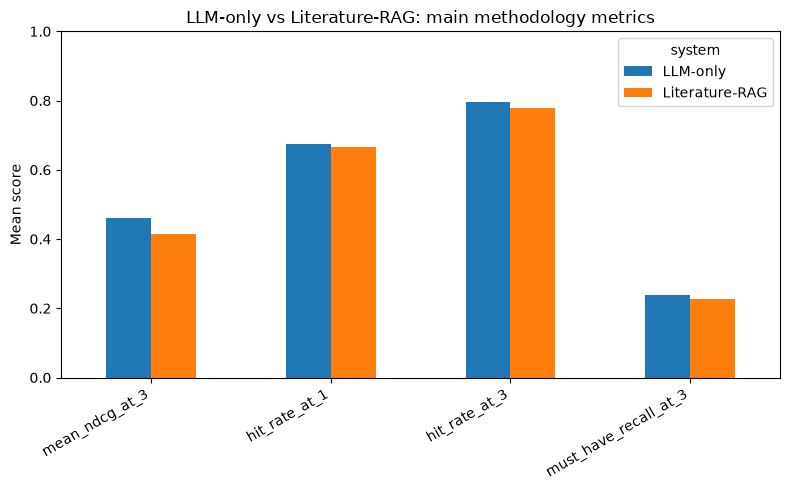

In [73]:
plot_summary = overall_summary_df.set_index("system")[[
    "mean_ndcg_at_3",
    "hit_rate_at_1",
    "hit_rate_at_3",
    "must_have_recall_at_3",
]]

ax = plot_summary.T.plot(kind="bar", figsize=(8, 5))
ax.set_ylim(0, 1)
ax.set_ylabel("Mean score")
ax.set_title("LLM-only vs Literature-RAG: main methodology metrics")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

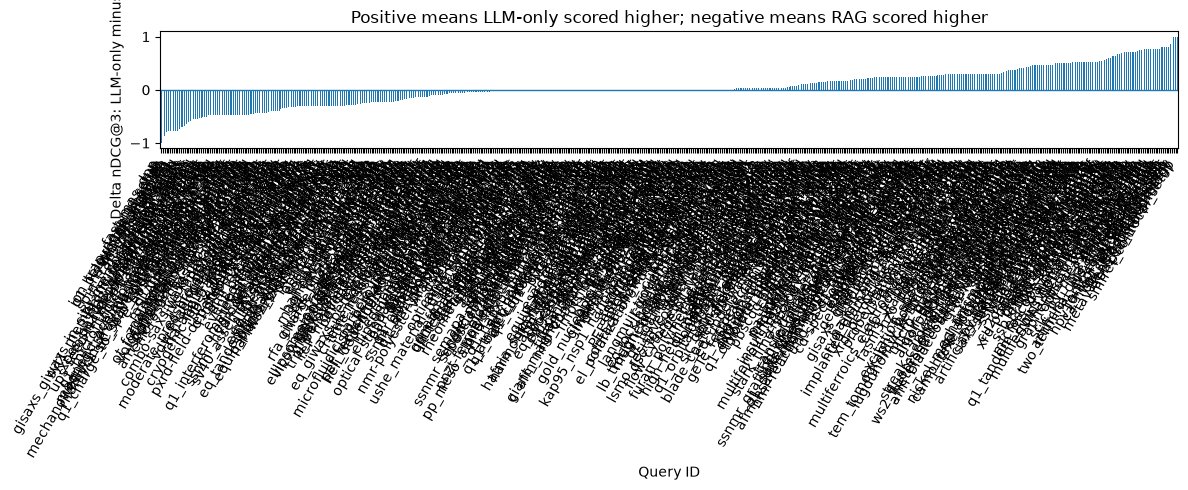

In [74]:
# Per-query paired nDCG@3 differences.
delta_plot_df = paired_delta_df.sort_values("delta_llm_minus_rag_ndcg_at_3").copy()
ax = delta_plot_df.plot(
    x="query_id",
    y="delta_llm_minus_rag_ndcg_at_3",
    kind="bar",
    figsize=(12, 5),
    legend=False,
)
ax.axhline(0, linewidth=1)
ax.set_xlabel("Query ID")
ax.set_ylabel("Delta nDCG@3: LLM-only minus RAG")
ax.set_title("Positive means LLM-only scored higher; negative means RAG scored higher")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Fallback summary


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# If query_score_df is not already loaded, uncomment and adapt this:
# query_score_df = pd.read_csv("data/evaluation/llm_only_vs_rag/llm_only_vs_rag_query_scores.csv")

OUTPUT_DIR = Path("data/evaluation/llm_only_vs_rag")
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path("llm_only_vs_rag")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Only RAG has fallback information
rag_fallback_df = query_score_df[
    (query_score_df["system"] == "Literature-RAG")
    & (query_score_df["run_status"] == "completed")
].copy()

rag_fallback_df = rag_fallback_df[
    rag_fallback_df["fallback_fraction"].notna()
].copy()

# Make sure fallback fraction is clipped to [0, 1]
rag_fallback_df["fallback_fraction"] = rag_fallback_df["fallback_fraction"].clip(0, 1)

print("Number of RAG queries with fallback information:", len(rag_fallback_df))
display(
    rag_fallback_df[
        ["query_id", "query_type", "fallback_fraction", "ndcg_at_3", "hit_at_3", "must_have_recall_at_3"]
    ].head()
)

Number of RAG queries with fallback information: 561


,query_id,query_type,fallback_fraction,ndcg_at_3,hit_at_3,must_have_recall_at_3
1,1d_tsc_verification,broad_diagnostic,0.2,1.000000,True,0.50
3,2d_edge_modes,broad_diagnostic,0.4,0.469279,True,0.25
5,2des-cross-pol,specific,0.8,0.469279,True,0.25
7,2des-lh2-instrument,specific,0.7,0.765361,True,0.25
9,2des_77k_lhcii,specific,0.9,0.469279,True,0.25


In [76]:
def fallback_used_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.assign(fallback_used=df["fallback_fraction"] > 0)
        .groupby("fallback_used")
        .agg(
            n_queries=("query_id", "nunique"),
            mean_ndcg_at_3=("ndcg_at_3", "mean"),
            median_ndcg_at_3=("ndcg_at_3", "median"),
            hit_rate_at_3=("hit_at_3", "mean"),
            mean_fallback_fraction=("fallback_fraction", "mean"),
        )
        .reset_index()
    )

    total = summary["n_queries"].sum()
    summary["query_percentage"] = 100 * summary["n_queries"] / total

    summary["fallback_used"] = summary["fallback_used"].map({
        False: "No fallback used",
        True: "Fallback used",
    })

    return summary


fallback_used_summary_df = fallback_used_summary(rag_fallback_df)

display(fallback_used_summary_df)

fallback_used_summary_df.to_csv(
    OUTPUT_DIR / "rag_fallback_used_summary.csv",
    index=False,
)

,fallback_used,n_queries,mean_ndcg_at_3,median_ndcg_at_3,hit_rate_at_3,mean_fallback_fraction,query_percentage
0,Fallback used,561,0.413843,0.469279,0.777184,0.730481,100.0


But it in bins

In [77]:
def make_fallback_bucket_summary(df: pd.DataFrame, step: float) -> pd.DataFrame:
    """
    Groups RAG queries by fallback_fraction into equal-width bins.

    step=0.25 gives 25% bins:
        0–25%, 25–50%, 50–75%, 75–100%

    step=0.10 gives 10% bins:
        0–10%, 10–20%, ..., 90–100%
    """
    edges = np.round(np.arange(0, 1 + step, step), 10)

    # Safety check to ensure 1.0 is included exactly
    if edges[-1] < 1.0:
        edges = np.append(edges, 1.0)

    labels = [
        f"{int(round(edges[i] * 100))}–{int(round(edges[i + 1] * 100))}%"
        for i in range(len(edges) - 1)
    ]

    bucketed = df.copy()
    bucketed["fallback_bucket"] = pd.cut(
        bucketed["fallback_fraction"],
        bins=edges,
        labels=labels,
        include_lowest=True,
        right=True,
    )

    summary = (
        bucketed
        .groupby("fallback_bucket", observed=False)
        .agg(
            n_queries=("query_id", "nunique"),
            mean_ndcg_at_3=("ndcg_at_3", "mean"),
            median_ndcg_at_3=("ndcg_at_3", "median"),
            std_ndcg_at_3=("ndcg_at_3", "std"),
            hit_rate_at_3=("hit_at_3", "mean"),
            must_have_recall_at_3=("must_have_recall_at_3", "mean"),
            mean_fallback_fraction=("fallback_fraction", "mean"),
        )
        .reset_index()
    )

    total_queries = summary["n_queries"].sum()
    summary["query_fraction"] = summary["n_queries"] / total_queries
    summary["query_percentage"] = 100 * summary["query_fraction"]

    return summary


rag_fallback_bucket_25_df = make_fallback_bucket_summary(rag_fallback_df, step=0.25)
rag_fallback_bucket_10_df = make_fallback_bucket_summary(rag_fallback_df, step=0.10)

print("25% fallback bins")
display(rag_fallback_bucket_25_df)

print("10% fallback bins")
display(rag_fallback_bucket_10_df)

rag_fallback_bucket_25_df.to_csv(
    OUTPUT_DIR / "rag_fallback_bucket_summary_25pct.csv",
    index=False,
)

rag_fallback_bucket_10_df.to_csv(
    OUTPUT_DIR / "rag_fallback_bucket_summary_10pct.csv",
    index=False,
)

25% fallback bins


,fallback_bucket,n_queries,mean_ndcg_at_3,median_ndcg_at_3,std_ndcg_at_3,hit_rate_at_3,must_have_recall_at_3,mean_fallback_fraction,query_fraction,query_percentage
0,0–25%,5,0.659216,0.765361,0.382263,0.800000,0.366667,0.16,0.008913,0.891266
1,25–50%,89,0.452748,0.469279,0.286636,0.808989,0.274567,0.433708,0.158645,15.864528
2,50–75%,177,0.423447,0.469279,0.270750,0.796610,0.237524,0.660452,0.315508,31.550802
3,75–100%,290,0.391812,0.469279,0.262883,0.755172,0.204715,0.874138,0.516934,51.693405


10% fallback bins


,fallback_bucket,n_queries,mean_ndcg_at_3,median_ndcg_at_3,std_ndcg_at_3,hit_rate_at_3,must_have_recall_at_3,mean_fallback_fraction,query_fraction,query_percentage
0,0–10%,2,0.382680,0.382680,0.541192,0.500000,0.250000,0.1,0.003565,0.356506
1,10–20%,3,0.843574,0.765361,0.135469,1.000000,0.444444,0.2,0.005348,0.534759
2,20–30%,17,0.483923,0.469279,0.299865,0.823529,0.292157,0.3,0.030303,3.030303
3,30–40%,25,0.458428,0.469279,0.259392,0.840000,0.315143,0.4,0.044563,4.456328
4,40–50%,47,0.438450,0.469279,0.300350,0.787234,0.246014,0.5,0.083779,8.377897
5,50–60%,70,0.404692,0.469279,0.283329,0.785714,0.213929,0.6,0.124777,12.477718
6,60–70%,107,0.435717,0.469279,0.262823,0.803738,0.252960,0.7,0.190731,19.073084
7,70–80%,127,0.414768,0.469279,0.232135,0.826772,0.214211,0.8,0.226381,22.638146
8,80–90%,111,0.388584,0.469279,0.263610,0.765766,0.207446,0.9,0.197861,19.786096
9,90–100%,52,0.342635,0.469279,0.323721,0.557692,0.175748,1.0,0.092692,9.269162


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_full_text_paper_summary(df: pd.DataFrame, max_papers: int = 10) -> pd.DataFrame:
    """
    Summarize RAG performance by the exact number of full-text papers retrieved.
    """

    full_text_df = df.copy()

    # Prefer an explicit count column if available
    if "num_full_text_success" in full_text_df.columns:
        full_text_df["num_full_text_papers"] = full_text_df["num_full_text_success"]

    # Otherwise derive count from fraction * max_papers
    elif "full_text_success_fraction" in full_text_df.columns:
        full_text_df["num_full_text_papers"] = (
            full_text_df["full_text_success_fraction"] * max_papers
        ).round()

    else:
        raise ValueError(
            "Missing both 'num_full_text_success' and "
            "'full_text_success_fraction'. Cannot compute full-text paper count."
        )

    full_text_df["num_full_text_papers"] = (
        full_text_df["num_full_text_papers"]
        .fillna(0)
        .astype(int)
        .clip(0, max_papers)
    )

    summary = (
        full_text_df
        .groupby("num_full_text_papers")
        .agg(
            n_queries=("query_id", "nunique"),
            mean_ndcg_at_3=("ndcg_at_3", "mean"),
            median_ndcg_at_3=("ndcg_at_3", "median"),
            std_ndcg_at_3=("ndcg_at_3", "std"),
            hit_rate_at_3=("hit_at_3", "mean"),
            must_have_recall_at_3=("must_have_recall_at_3", "mean"),
            mean_fallback_fraction=("fallback_fraction", "mean"),
            mean_full_text_success_fraction=("full_text_success_fraction", "mean"),
        )
        .reset_index()
    )

    # Ensure all values 0--10 are visible, even if no query falls into a category
    all_counts = pd.DataFrame({
        "num_full_text_papers": range(max_papers + 1)
    })

    summary = all_counts.merge(
        summary,
        on="num_full_text_papers",
        how="left",
    )

    summary["n_queries"] = summary["n_queries"].fillna(0).astype(int)

    total_queries = summary["n_queries"].sum()
    summary["query_percentage"] = np.where(
        total_queries > 0,
        100 * summary["n_queries"] / total_queries,
        0,
    )

    return summary


rag_full_text_paper_summary_df = make_full_text_paper_summary(
    rag_fallback_df,
    max_papers=10,
)

display(rag_full_text_paper_summary_df)

,num_full_text_papers,n_queries,mean_ndcg_at_3,median_ndcg_at_3,std_ndcg_at_3,hit_rate_at_3,must_have_recall_at_3,mean_fallback_fraction,mean_full_text_success_fraction,query_percentage
0,0,52,0.342635,0.469279,0.323721,0.557692,0.175748,1.0,0.0,9.269162
1,1,112,0.385114,0.469279,0.264976,0.758929,0.205577,0.899107,0.1,19.964349
2,2,126,0.418060,0.469279,0.230066,0.833333,0.215911,0.8,0.2,22.459893
3,3,107,0.435717,0.469279,0.262823,0.803738,0.252960,0.7,0.3,19.073084
4,4,70,0.404692,0.469279,0.283329,0.785714,0.213929,0.6,0.4,12.477718
5,5,47,0.438450,0.469279,0.300350,0.787234,0.246014,0.5,0.5,8.377897
6,6,25,0.458428,0.469279,0.259392,0.840000,0.315143,0.4,0.6,4.456328
7,7,17,0.483923,0.469279,0.299865,0.823529,0.292157,0.3,0.7,3.030303
8,8,3,0.843574,0.765361,0.135469,1.000000,0.444444,0.2,0.8,0.534759
9,9,2,0.382680,0.382680,0.541192,0.500000,0.250000,0.1,0.9,0.356506


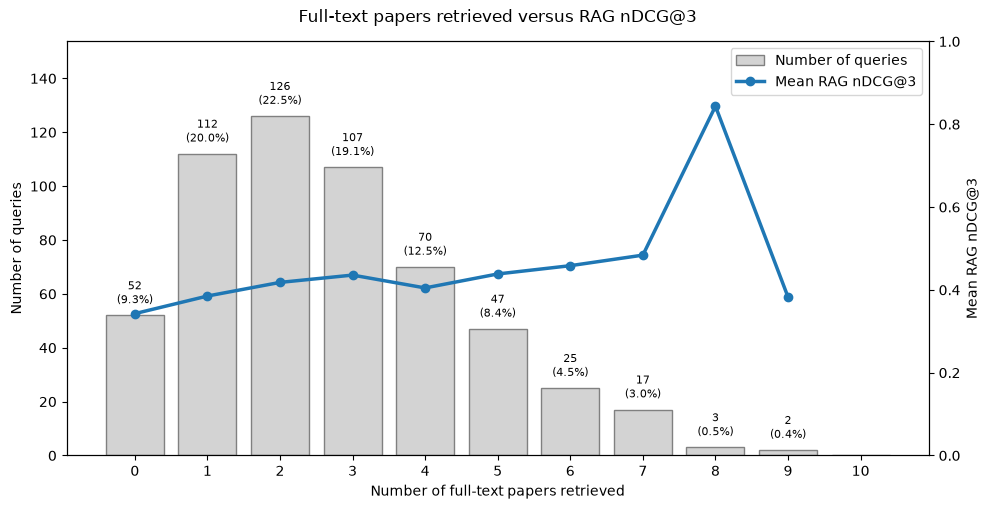

In [79]:
def plot_full_text_paper_summary(summary_df: pd.DataFrame, title: str) -> None:
    """
    Bar plot: number of queries for each exact number of full-text papers.
    Line plot: mean RAG nDCG@3.
    """

    plot_df = summary_df.copy()

    fig, ax1 = plt.subplots(figsize=(10, 5.2))

    x = np.arange(len(plot_df))
    counts = plot_df["n_queries"].fillna(0)
    mean_ndcg = plot_df["mean_ndcg_at_3"]

    # Bars: number of queries
    ax1.bar(
        x,
        counts,
        color="lightgray",
        edgecolor="gray",
        zorder=1,
        label="Number of queries",
    )

    ax1.set_xlabel("Number of full-text papers retrieved")
    ax1.set_ylabel("Number of queries")
    ax1.set_xticks(x)
    ax1.set_xticklabels(plot_df["num_full_text_papers"].astype(int))
    ax1.set_axisbelow(True)

    # Add extra spacing above the tallest bar
    max_count = counts.max()
    ax1.set_ylim(0, max_count * 1.22)

    # Count labels above bars
    label_offset = max_count * 0.025

    for xi, count, pct in zip(x, counts, plot_df["query_percentage"]):
        if count > 0:
            ax1.text(
                xi,
                count + label_offset,
                f"{int(count)}\n({pct:.1f}%)",
                ha="center",
                va="bottom",
                fontsize=8,
                zorder=3,
            )

    # Line: mean RAG nDCG@3
    ax2 = ax1.twinx()
    ax2.patch.set_visible(False)
    ax2.set_zorder(ax1.get_zorder() + 1)

    ax2.plot(
        x,
        mean_ndcg,
        color="tab:blue",
        marker="o",
        linewidth=2.5,
        markersize=6,
        zorder=5,
        label="Mean RAG nDCG@3",
    )

    ax2.set_ylabel("Mean RAG nDCG@3")
    ax2.set_ylim(0, 1)

    # Combined legend
    handles_1, labels_1 = ax1.get_legend_handles_labels()
    handles_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles_1 + handles_2,
        labels_1 + labels_2,
        loc="upper right",
    )

    plt.title(title, pad=14)
    plt.tight_layout()
    plt.show()


plot_full_text_paper_summary(
    rag_full_text_paper_summary_df,
    "Full-text papers retrieved versus RAG nDCG@3",
)

In [80]:
def get_queries_with_min_full_text_papers(
    rag_df: pd.DataFrame,
    min_full_text_papers: int,
    max_papers: int = 10,
) -> np.ndarray:
    """
    Return query IDs where the RAG system retrieved at least min_full_text_papers full-text papers.
    """

    df = rag_df.copy()

    if "num_full_text_success" in df.columns:
        df["num_full_text_papers"] = df["num_full_text_success"]

    elif "full_text_success_fraction" in df.columns:
        df["num_full_text_papers"] = (
            df["full_text_success_fraction"] * max_papers
        ).round()

    else:
        raise ValueError(
            "Missing both 'num_full_text_success' and "
            "'full_text_success_fraction'. Cannot compute full-text paper count."
        )

    df["num_full_text_papers"] = (
        df["num_full_text_papers"]
        .fillna(0)
        .astype(int)
        .clip(0, max_papers)
    )

    query_ids = (
        df[df["num_full_text_papers"] >= min_full_text_papers]["query_id"]
        .dropna()
        .unique()
    )

    return query_ids

In [82]:
def compare_llm_vs_rag_for_min_full_text(
    query_score_df: pd.DataFrame,
    rag_fallback_df: pd.DataFrame,
    min_full_text_papers: int,
    max_papers: int = 10,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Compare LLM-only and Literature-RAG on queries where RAG retrieved
    at least min_full_text_papers full-text papers.
    """

    selected_query_ids = get_queries_with_min_full_text_papers(
        rag_df=rag_fallback_df,
        min_full_text_papers=min_full_text_papers,
        max_papers=max_papers,
    )

    subset_df = query_score_df[
        query_score_df["query_id"].isin(selected_query_ids)
    ].copy()

    subset_df = subset_df[
        subset_df["run_status"] == "completed"
    ].copy()

    print(
        f"Queries where RAG retrieved at least "
        f"{min_full_text_papers} full-text papers: {len(selected_query_ids)}"
    )

    metrics = [
        "num_returned_equipment",
        "has_returned_equipment",
        "ndcg_at_1",
        "ndcg_at_3",
        "ndcg_at_5",
        "hit_at_1",
        "hit_at_3",
        "hit_at_5",
        "must_have_recall_at_1",
        "must_have_recall_at_3",
        "must_have_recall_at_5",
        "relevant_recall_at_1",
        "relevant_recall_at_3",
        "relevant_recall_at_5",
    ]

    available_metrics = [m for m in metrics if m in subset_df.columns]

    summary_df = (
        subset_df
        .groupby("system")[available_metrics]
        .mean()
        .reset_index()
    )

    n_queries_per_system = (
        subset_df
        .groupby("system")["query_id"]
        .nunique()
        .reset_index(name="n_queries")
    )

    summary_df = summary_df.merge(
        n_queries_per_system,
        on="system",
        how="left",
    )

    cols = ["system", "n_queries"] + [
        col for col in summary_df.columns
        if col not in ["system", "n_queries"]
    ]
    summary_df = summary_df[cols]

    paired_df = (
        subset_df
        .pivot_table(
            index=["query_id", "query_type"],
            columns="system",
            values=available_metrics,
            aggfunc="first",
        )
    )

    paired_df.columns = [
        f"{system}_{metric}" for metric, system in paired_df.columns
    ]

    paired_df = paired_df.reset_index()

    for metric in available_metrics:
        llm_col = f"LLM-only_{metric}"
        rag_col = f"Literature-RAG_{metric}"

        if llm_col in paired_df.columns and rag_col in paired_df.columns:
            # Convert booleans to numbers so True/False can be compared as 1/0
            llm_values = paired_df[llm_col]
            rag_values = paired_df[rag_col]

            if llm_values.dtype == bool or rag_values.dtype == bool:
                llm_values = llm_values.astype(float)
                rag_values = rag_values.astype(float)
            else:
                llm_values = pd.to_numeric(llm_values, errors="coerce")
                rag_values = pd.to_numeric(rag_values, errors="coerce")

            paired_df[f"delta_llm_minus_rag_{metric}"] = (
                llm_values - rag_values
            )

    selected_metrics = [
        "ndcg_at_1",
        "ndcg_at_3",
        "ndcg_at_5",
        "hit_at_1",
        "hit_at_3",
        "must_have_recall_at_3",
        "relevant_recall_at_3",
        "num_returned_equipment",
    ]

    rows = []

    for metric in selected_metrics:
        delta_col = f"delta_llm_minus_rag_{metric}"

        if delta_col not in paired_df.columns:
            continue

        valid_delta = paired_df[delta_col].dropna()

        rows.append({
            "metric": metric,
            "n_queries": len(valid_delta),
            "llm_only_better": int((valid_delta > 0).sum()),
            "rag_better": int((valid_delta < 0).sum()),
            "tied": int((valid_delta == 0).sum()),
            "mean_delta_llm_minus_rag": valid_delta.mean(),
        })

    win_tie_loss_df = pd.DataFrame(rows)

    return summary_df, paired_df, win_tie_loss_df

In [83]:
summary_min_2_full_text, paired_min_2_full_text, win_loss_min_2_full_text = (
    compare_llm_vs_rag_for_min_full_text(
        query_score_df=query_score_df,
        rag_fallback_df=rag_fallback_df,
        min_full_text_papers=2,
        max_papers=10,
    )
)

display(summary_min_2_full_text)
display(win_loss_min_2_full_text)

Queries where RAG retrieved at least 2 full-text papers: 397


,system,n_queries,num_returned_equipment,ndcg_at_1,ndcg_at_3,ndcg_at_5,hit_at_1,hit_at_3,hit_at_5,must_have_recall_at_1,must_have_recall_at_3,must_have_recall_at_5,relevant_recall_at_1,relevant_recall_at_3,relevant_recall_at_5
0,LLM-only,397,4.405542,0.631882,0.450680,0.376951,0.659950,0.778338,0.801008,0.172276,0.234040,0.247490,0.112777,0.173283,0.192210
1,Literature-RAG,397,3.045340,0.669306,0.431275,0.348101,0.690176,0.811083,0.813602,0.175806,0.240509,0.250168,0.121873,0.174179,0.184235


,metric,n_queries,llm_only_better,rag_better,tied,mean_delta_llm_minus_rag
0,ndcg_at_1,397,70,92,235,-0.037424
1,ndcg_at_3,397,168,142,87,0.019405
2,ndcg_at_5,397,190,145,62,0.028850
3,hit_at_1,397,66,78,253,-0.030227
4,hit_at_3,397,45,58,294,-0.032746
5,must_have_recall_at_3,396,78,94,224,-0.006469
6,relevant_recall_at_3,397,104,99,194,-0.000895
7,num_returned_equipment,397,280,47,70,1.360202


In [84]:
summary_min_3_full_text, paired_min_3_full_text, win_loss_min_3_full_text = (
    compare_llm_vs_rag_for_min_full_text(
        query_score_df=query_score_df,
        rag_fallback_df=rag_fallback_df,
        min_full_text_papers=3,
        max_papers=10,
    )
)

display(summary_min_3_full_text)
display(win_loss_min_3_full_text)

Queries where RAG retrieved at least 3 full-text papers: 271


,system,n_queries,num_returned_equipment,ndcg_at_1,ndcg_at_3,ndcg_at_5,hit_at_1,hit_at_3,hit_at_5,must_have_recall_at_1,must_have_recall_at_3,must_have_recall_at_5,relevant_recall_at_1,relevant_recall_at_3,relevant_recall_at_5
0,LLM-only,271,4.461255,0.629415,0.450368,0.376197,0.656827,0.785978,0.800738,0.170952,0.234369,0.247183,0.111847,0.169429,0.186734
1,Literature-RAG,271,3.040590,0.672641,0.437420,0.351495,0.693727,0.800738,0.804428,0.182090,0.251989,0.257513,0.120568,0.175709,0.184283


,metric,n_queries,llm_only_better,rag_better,tied,mean_delta_llm_minus_rag
0,ndcg_at_1,271,48,63,160,-0.043226
1,ndcg_at_3,271,111,102,58,0.012948
2,ndcg_at_5,271,129,102,40,0.024702
3,hit_at_1,271,45,55,171,-0.036900
4,hit_at_3,271,33,37,201,-0.014760
5,must_have_recall_at_3,270,46,66,158,-0.017619
6,relevant_recall_at_3,271,68,74,129,-0.006281
7,num_returned_equipment,271,197,28,46,1.420664


In [87]:
summary_min_3_full_text, paired_min_3_full_text, win_loss_min_3_full_text = (
    compare_llm_vs_rag_for_min_full_text(
        query_score_df=query_score_df,
        rag_fallback_df=rag_fallback_df,
        min_full_text_papers=5,
        max_papers=10,
    )
)

display(summary_min_3_full_text)
display(win_loss_min_3_full_text)

Queries where RAG retrieved at least 5 full-text papers: 94


,system,n_queries,num_returned_equipment,ndcg_at_1,ndcg_at_3,ndcg_at_5,hit_at_1,hit_at_3,hit_at_5,must_have_recall_at_1,must_have_recall_at_3,must_have_recall_at_5,relevant_recall_at_1,relevant_recall_at_3,relevant_recall_at_5
0,LLM-only,94,4.37234,0.603343,0.433512,0.368346,0.617021,0.755319,0.787234,0.170891,0.241961,0.267409,0.109376,0.164928,0.187276
1,Literature-RAG,94,3.06383,0.717325,0.463730,0.373446,0.734043,0.808511,0.819149,0.209780,0.279519,0.283103,0.143726,0.198311,0.201870


,metric,n_queries,llm_only_better,rag_better,tied,mean_delta_llm_minus_rag
0,ndcg_at_1,94,16,28,50,-0.113982
1,ndcg_at_3,94,37,40,17,-0.030218
2,ndcg_at_5,94,43,40,11,-0.005100
3,hit_at_1,94,15,26,53,-0.117021
4,hit_at_3,94,10,15,69,-0.053191
5,must_have_recall_at_3,93,16,27,50,-0.037558
6,relevant_recall_at_3,94,19,31,44,-0.033383
7,num_returned_equipment,94,67,9,18,1.308511


## Use where at least 3 papers could be read

## Save output tables

The notebook exports CSV files for thesis tables and error analysis.

In [37]:
query_score_path = OUTPUT_DIR / "llm_only_vs_rag_query_scores.csv"
overall_summary_path = OUTPUT_DIR / "llm_only_vs_rag_overall_summary.csv"
paired_delta_path = OUTPUT_DIR / "llm_only_vs_rag_paired_deltas.csv"
paired_summary_path = OUTPUT_DIR / "llm_only_vs_rag_paired_summary.csv"
by_query_type_path = OUTPUT_DIR / "llm_only_vs_rag_by_query_type.csv"
fallback_diagnostic_path = OUTPUT_DIR / "llm_only_vs_rag_fallback_diagnostics.csv"
llm_better_examples_path = OUTPUT_DIR / "llm_only_better_examples.csv"
rag_better_examples_path = OUTPUT_DIR / "rag_better_examples.csv"

query_score_df.to_csv(query_score_path, index=False)
overall_summary_df.to_csv(overall_summary_path, index=False)
paired_delta_df.to_csv(paired_delta_path, index=False)
paired_summary_df.to_csv(paired_summary_path, index=False)
by_query_type_df.to_csv(by_query_type_path, index=False)
fallback_diagnostic_df.to_csv(fallback_diagnostic_path, index=False)
llm_better_examples_df.to_csv(llm_better_examples_path, index=False)
rag_better_examples_df.to_csv(rag_better_examples_path, index=False)

print("Wrote:")
for path in [
    query_score_path,
    overall_summary_path,
    paired_delta_path,
    paired_summary_path,
    by_query_type_path,
    fallback_diagnostic_path,
    llm_better_examples_path,
    rag_better_examples_path,
]:
    print("-", path)

Wrote:
- llm_only_vs_rag/llm_only_vs_rag_query_scores.csv
- llm_only_vs_rag/llm_only_vs_rag_overall_summary.csv
- llm_only_vs_rag/llm_only_vs_rag_paired_deltas.csv
- llm_only_vs_rag/llm_only_vs_rag_paired_summary.csv
- llm_only_vs_rag/llm_only_vs_rag_by_query_type.csv
- llm_only_vs_rag/llm_only_vs_rag_fallback_diagnostics.csv
- llm_only_vs_rag/llm_only_better_examples.csv
- llm_only_vs_rag/rag_better_examples.csv


## Suggested thesis wording

After running the notebook on the full LLM-only output, you can adapt this sentence:

> The LLM-only baseline and the literature-grounded RAG system were evaluated on the same benchmark queries using the same output schema. Recommendation quality was compared using `nDCG@3`, `Hit Rate@1`, `Hit Rate@3`, and `Must-have Recall@3`. Because the LLM-only baseline does not perform retrieval, fallback and evidence statistics were reported only as diagnostics for the RAG system and were not included in the recommendation-quality score.

If the LLM-only system scores higher, add this nuance:

> The LLM-only baseline often produced broader equipment-family names, which can align more directly with the benchmark labels. In contrast, the RAG system sometimes produced more specific literature-derived equipment descriptions. Therefore, automatic benchmark matching may under-credit scientifically valid RAG recommendations when their terminology differs from the expected labels.